In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Loaded Successfully!")
print(X.head())

Dataset Loaded Successfully!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
      )

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)  # Tree doesn't need scaling


DecisionTreeRegressor(random_state=42)

In [6]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)


In [7]:
def evaluate_model(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {model_name}")
    print(f"RMSE: {rmse}")
    print(f"R² Score: {r2}")

    return rmse, r2

rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
rmse_dt, r2_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")


📊 Linear Regression
RMSE: 0.7455813830127763
R² Score: 0.575787706032451

📊 Ridge Regression
RMSE: 0.7455567442814779
R² Score: 0.5758157428913684

📊 Decision Tree
RMSE: 0.7037294974840077
R² Score: 0.622075845135081


In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_dt],
    "R2 Score": [r2_lr, r2_ridge, r2_dt]
})

print("\n📋 Model Comparison:")
print(results)


📋 Model Comparison:
               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745557  0.575816
2      Decision Tree  0.703729  0.622076


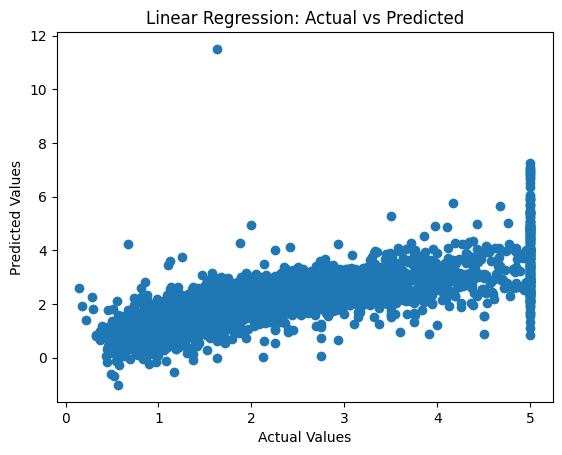

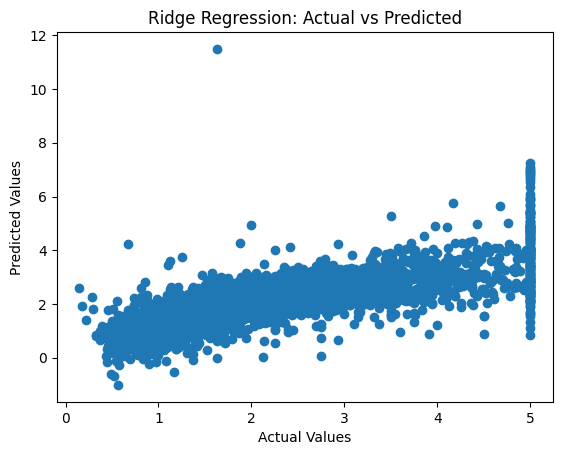

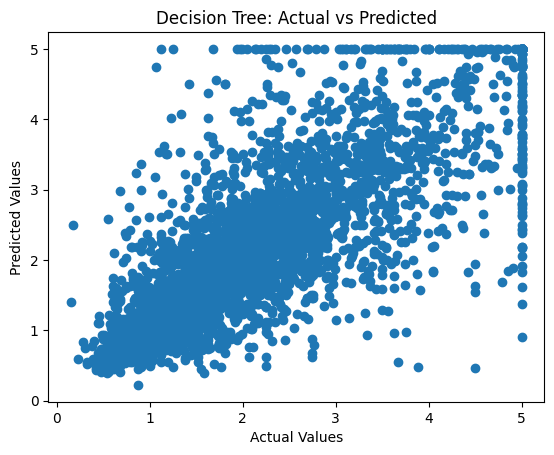

In [9]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()


In [10]:
best_model = results.loc[results["R2 Score"].idxmax()]
print("\n🏆 Best Model:")
print(best_model)



🏆 Best Model:
Model       Decision Tree
RMSE             0.703729
R2 Score         0.622076
Name: 2, dtype: object
